# 00 — Exploración del dataset Black Basta

Inspección del fichero `blackbasta_chats.json`:  
formato, estadísticas básicas, actores, canales y distribución temporal.

## 0. Setup

In [1]:
# sys nos permite modificar la lista de rutas donde Python busca módulos.
# Esto es necesario para que Python encuentre nuestro código en la carpeta 'src'.
import sys

# Path es la herramienta de Python para manejar rutas de archivos de forma segura
# y portátil (funciona igual en Windows, Mac y Linux).
from pathlib import Path

# Añadimos la carpeta 'src' al principio de la lista de búsqueda de módulos.
# str(...) convierte el objeto Path a texto, que es lo que sys.path.insert espera.
# resolve() convierte la ruta relativa en una ruta absoluta (para evitar confusiones).
sys.path.insert(0, str(Path('src').resolve()))

# re es el módulo de expresiones regulares de Python, que permite buscar patrones
# en texto. Lo usamos para contar objetos {} en el fichero crudo.
import re

# pandas es la librería principal para trabajar con tablas de datos (DataFrames).
import pandas as pd

# matplotlib es la librería más popular para hacer gráficas en Python.
# pyplot es el submódulo que tiene las funciones de dibujo (como plt.plot, plt.show...).
import matplotlib.pyplot as plt

# Importamos nuestra función personalizada de carga desde src/loaders.py.
# Esta función sabe cómo leer el formato especial del fichero de Black Basta.
from loaders import load_blackbasta

# Definimos la ruta al fichero de chats crudo. Path(...) crea un objeto ruta.
# Adapta esta ruta a donde tengas el fichero de chats de Black Basta.
# Convención del repo: pon los datos brutos en BlackBasta/data_bruto/
RAW_FILE = Path('../data_Vruto/BlackBasta/raw/blackbasta_chats.json')

# Verificamos que el fichero realmente existe antes de continuar.
# Si no existe, assert lanza un error con el mensaje que escribimos.
# Esto es útil para detectar problemas de ruta desde el principio.
assert RAW_FILE.exists(), f'No se encuentra {RAW_FILE}'

# Mostramos el tamaño del fichero en megabytes para tener una idea de cuánto pesa.
# stat().st_size devuelve el tamaño en bytes; dividir entre 1024**2 convierte a MB.
print(f'Tamaño fichero: {RAW_FILE.stat().st_size / 1024**2:.1f} MB')

Tamaño fichero: 47.6 MB


## 1. Inspección del formato raw

In [2]:
# Abrimos el fichero para leerlo como texto plano.
# encoding='utf-8' indica que el fichero está codificado en UTF-8 (el estándar moderno).
# errors='replace' hace que los caracteres raros no causen un error: se reemplazan
# por un símbolo especial en lugar de interrumpir la lectura.
# La palabra clave 'with' garantiza que el fichero se cierra automáticamente
# al terminar el bloque, aunque ocurra un error.
with open(RAW_FILE, encoding='utf-8', errors='replace') as f:
    # f.read() lee todo el contenido del fichero de una sola vez y lo guarda
    # en la variable 'content' como una cadena de texto muy larga.
    content = f.read()

# Mostramos los primeros 600 caracteres del fichero para ver cómo está estructurado.
# Esto nos permite entender el formato antes de parsearlo con código.
print('=== Primeros 600 caracteres ===')
print(content[:600])
print()

# Mostramos cuántos caracteres tiene el fichero completo.
# La coma en {:,} hace que los números grandes se muestren con separador de miles.
print(f'Tamaño total: {len(content):,} caracteres')

# Contamos cuántos bloques de mensaje hay buscando líneas que empiecen con '{'.
# Cada mensaje del chat está encerrado entre llaves { }, así que contar
# las llaves de apertura nos da una estimación del número total de mensajes.
# chr(10) es el carácter de salto de línea '\n' escrito de otra forma.
print(f'Objetos {{}} detectados: {content.count(chr(10) + "{"):,}')

=== Primeros 600 caracteres ===
{
    timestamp: 2023-09-18 13:35:07,
    chat_id: !VdvDXHFZwWDpIAtpCj:matrix.bestflowers247.online,
    sender_alias: @usernamenn:matrix.bestflowers247.online,
    message: BAZA
}
{
    timestamp: 2023-09-18 13:50:31,
    chat_id: !uJZKZVgGmmSiNvobZH:matrix.bestflowers247.online,
    sender_alias: @usernamess:matrix.bestflowers247.online,
    message: !!!
}
{
    timestamp: 2023-09-18 17:43:18,
    chat_id: !FtoGkSqUPiGjGNKkOl:matrix.bestflowers247.online,
    sender_alias: @usernameyy:matrix.bestflowers247.online,
    message: cpu 2core 2.4 ghz, 4 gb ram, 100 gb space x2
}
{
    timestamp: 2

Tamaño total: 46,056,190 caracteres
Objetos {} detectados: 195,964


In [3]:
# Esta celda busca un ejemplo real de mensaje que ocupe varias líneas,
# para mostrar cómo el formato maneja texto con saltos de línea dentro del campo 'message'.

# Buscamos la primera aparición de las triples comillas (```) en el fichero.
# El grupo Black Basta las usa para pegar bloques de texto como credenciales o código.
# find() devuelve la posición (índice) del primer carácter encontrado, o -1 si no existe.
idx = content.find('```')

# Solo procedemos si encontramos un bloque de triple comilla (idx > 0)
if idx > 0:
    # rfind('{', 0, idx) busca el último '{' ANTES de la posición idx.
    # Así encontramos el inicio del bloque de mensaje que contiene el backtick.
    start = content.rfind('{', 0, idx)

    # find('}', idx) busca el primer '}' DESPUÉS de idx: ese es el cierre del bloque.
    # +1 para incluir el '}' en el fragmento que vamos a mostrar.
    end   = content.find('}', idx) + 1

    print('=== Ejemplo de mensaje multilínea ===')
    # Imprimimos el bloque completo: desde el '{' de apertura hasta el '}' de cierre.
    print(content[start:end])

=== Ejemplo de mensaje multilínea ===
{
    timestamp: 2023-09-18 17:44:42,
    chat_id: !FtoGkSqUPiGjGNKkOl:matrix.bestflowers247.online,
    sender_alias: @usernameyy:matrix.bestflowers247.online,
    message: ```
Login: usernameboy
Password: wet4vEtZq!D2sCRFdV!TRXwq3Tx!XC2ZzScX4vZQ

Login: username777
Password: FgTTe@fCSSC%qaFBTb43RXFVA1farXq!3Zc35wRT

Login: usernamehunter
Password: v1vAq24gV!45zB!xt!dxqAg4@ESaa!re4xDtr#v%

```
matrix.bestflowers247.online
}


## 2. Carga con el loader custom

In [4]:
# Llamamos a nuestra función personalizada que parsea el fichero crudo y
# devuelve un DataFrame de pandas con las columnas: timestamp, username,
# channel, message y source. Esta función está definida en src/loaders.py.
df = load_blackbasta(RAW_FILE)

# Imprimimos un resumen del dataset para verificar que la carga fue correcta:
print('=== DATASET BLACK BASTA ===')

# len(df) devuelve el número de filas, es decir, el número total de mensajes.
print(f'  Mensajes totales : {len(df):,}')

# nunique() cuenta cuántos valores distintos hay en una columna.
# En 'username' cuenta cuántas personas distintas participaron.
print(f'  Actores únicos   : {df.username.nunique()}')

# En 'channel' cuenta cuántos canales de chat distintos existen.
print(f'  Canales únicos   : {df.channel.nunique()}')

# min() y max() devuelven la fecha más antigua y la más reciente.
# .date() extrae solo la parte de fecha (sin la hora) para que sea más legible.
print(f'  Rango temporal   : {df.timestamp.min().date()} → {df.timestamp.max().date()}')

# isna().sum() cuenta cuántos timestamps son inválidos (NaT = "Not a Time").
# Si este número es 0, todos los mensajes tienen fecha válida.
print(f'  NaT timestamps   : {df.timestamp.isna().sum()}')
print()

# display() es una función especial de Jupyter que muestra el DataFrame
# con formato de tabla HTML, más fácil de leer que un print normal.
# head(5) devuelve solo las primeras 5 filas.
display(df.head(5))

=== DATASET BLACK BASTA ===
  Mensajes totales : 195,407
  Actores únicos   : 49
  Canales únicos   : 79
  Rango temporal   : 2023-09-18 → 2024-09-28
  NaT timestamps   : 0



,timestamp,username,channel,message,source
0,2023-09-18 13:35:07+00:00,usernamenn,VdvDXHFZwWDpIAtpCj,BAZA,blackbasta
1,2023-09-18 13:50:31+00:00,usernamess,uJZKZVgGmmSiNvobZH,!!!,blackbasta
2,2023-09-18 17:43:18+00:00,usernameyy,FtoGkSqUPiGjGNKkOl,"cpu 2core 2.4 ghz, 4 gb ram, 100 gb space x2",blackbasta
3,2023-09-18 17:44:42+00:00,usernameyy,FtoGkSqUPiGjGNKkOl,```\nLogin: usernameboy\nPassword: wet4vEtZq!D...,blackbasta
4,2023-09-18 17:47:48+00:00,usernameyy,kJVcUcyUsQhwBCuIPD,1,blackbasta


## 3. Actores

In [5]:
# Contamos cuántos mensajes tiene cada usuario.
# groupby('username') agrupa todas las filas del DataFrame por el valor de la columna 'username',
# de modo que todos los mensajes de un mismo usuario quedan juntos.
# .size() cuenta cuántas filas hay en cada grupo (es decir, cuántos mensajes tiene cada usuario).
# sort_values(ascending=False) ordena los resultados de mayor a menor número de mensajes,
# para que el usuario más activo aparezca primero.
actor_counts = df.groupby('username').size().sort_values(ascending=False)

print('Mensajes por actor:')

# to_string() convierte la serie a texto para que se muestre completa
# sin que pandas la recorte con "..." en el medio.
print(actor_counts.to_string())

Mensajes por actor:
username
usernamegg            83072
lapa                  26258
w                     13439
usernamenn             8509
usernameyy             7172
n3auxaxl               6386
usernameugway          6076
usernamess             5504
nickolas               3670
cameron777             3641
muaddib6               2454
ssd                    2281
burito                 2169
usernameww             1694
cob_crypt_ward         1678
usernamevv             1641
lincoln                1640
usernamemm             1609
usernamezz             1534
usernamett             1516
usernamecc             1417
chuck                  1374
tinker                 1163
mel                    1106
usernamejj              914
u123                    783
iamnurnazarov           734
usernamexx              698
usernameboy             659
manager361              577
usernamehunter          516
manager880              481
username777             471
usernameff              395
arslanshabbirmalik 

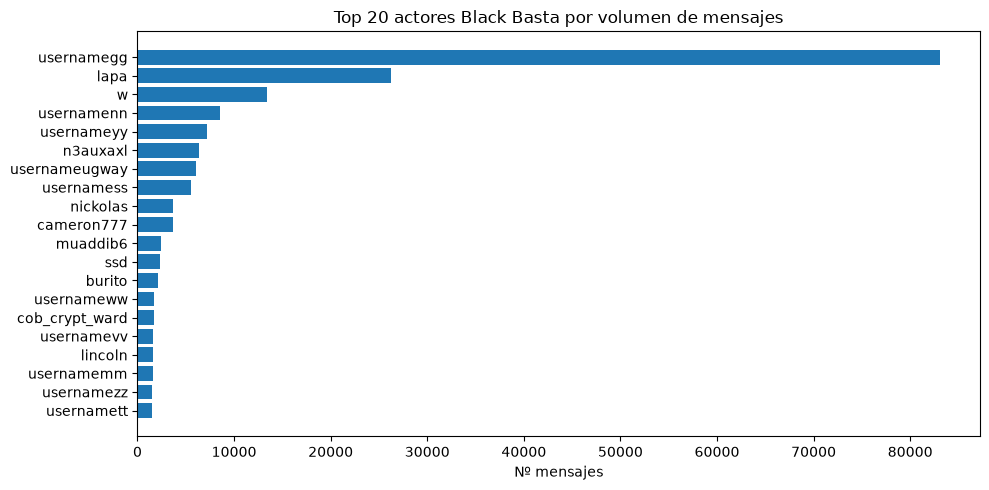

In [6]:
# Definimos cuántos actores queremos mostrar en el gráfico (los 20 más activos).
top_n = 20

# head(top_n) devuelve solo los primeros 'top_n' elementos de la serie ya ordenada.
top_actors = actor_counts.head(top_n)

# Creamos una figura de matplotlib para dibujar el gráfico.
# fig es el "lienzo" completo; ax es el "área de dibujo" dentro del lienzo.
# figsize=(10, 5) establece el tamaño en pulgadas: 10 de ancho x 5 de alto.
fig, ax = plt.subplots(figsize=(10, 5))

# Dibujamos un gráfico de barras horizontal (barh = horizontal bar chart).
# [::-1] invierte el orden para que el actor con más mensajes aparezca arriba.
# top_actors.index[::-1] son los nombres de los actores (eje Y).
# top_actors.values[::-1] son los números de mensajes (eje X).
ax.barh(top_actors.index[::-1], top_actors.values[::-1])

# Ponemos título y etiqueta al eje X.
ax.set_title(f'Top {top_n} actores Black Basta por volumen de mensajes')
ax.set_xlabel('Nº mensajes')

# tight_layout() ajusta automáticamente los márgenes para que nada se corte.
plt.tight_layout()

# show() renderiza y muestra la gráfica en el notebook.
plt.show()

## 4. Canales

In [7]:
# Hacemos lo mismo que con los actores pero ahora agrupando por canal de chat.
# Esto nos muestra en qué canales se concentró más la actividad del grupo.
# groupby('channel').size() cuenta los mensajes por canal.
# sort_values(ascending=False) los ordena de mayor a menor actividad.
channel_counts = df.groupby('channel').size().sort_values(ascending=False)

print(f'Top 20 canales por actividad:')

# head(20) muestra solo los 20 canales más activos.
# to_string() evita que pandas trunque la salida.
print(channel_counts.head(20).to_string())

Top 20 canales por actividad:
channel
nPsXVNwvPnfPbfsDcD    48933
BHEZrXZjNIsCKJMUYJ    20375
kJVcUcyUsQhwBCuIPD    13938
BOpqkyiMnBRfCPXwod    12470
RVxOPEuHMjKrYEQOpn    11180
LZIbnhnZMcQWZqmgzs     9997
SwOPmpPcbXMKVYoYrQ     9628
HOwizKpRWUvwqLnQAt     7264
EWFYRyuNbrMKmhIlzZ     4646
RMdGGuCKLBreGJPwlH     4216
MNovtbJOsRikjXSEYE     4162
movQbFbGmaZTcobDtK     3556
SrYuQddDovXeEsAmBh     3306
BJxdVvCxirwdeMdIiw     3062
HWdiqTZMSjlcPLzxjy     3035
FJNepzdTumLjULNYKA     2970
dqgXlehEZabQITeRcg     2842
sUYHRwQnrbjklKmEfq     2769
AMKxwPhkMPYAfABhRo     2372
CzaymkzesDwGIctmLA     2346


## 5. Actividad temporal

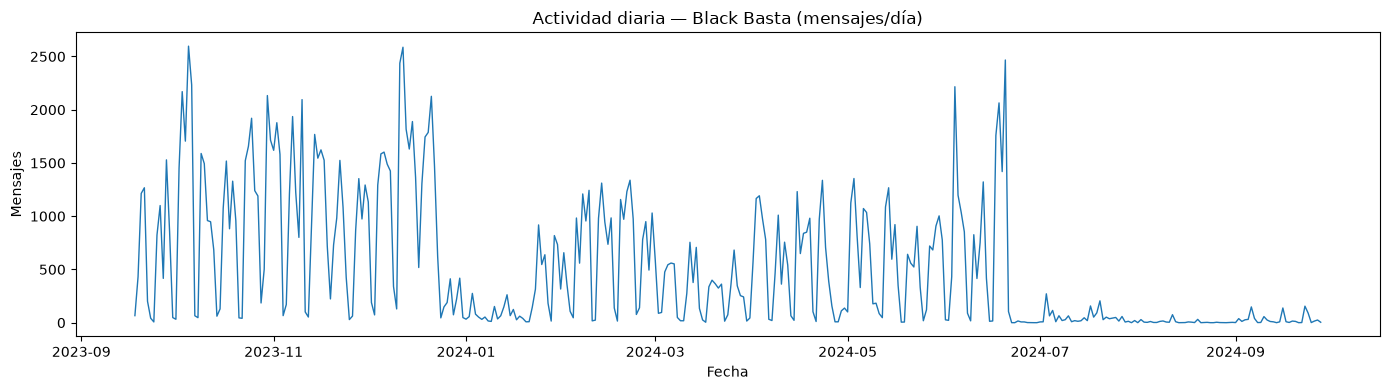


Pico máximo: 2023-10-05  (2,597 msgs)
Media diaria: 518 msgs/día


In [8]:
# Calculamos cuántos mensajes se enviaron cada día a lo largo del tiempo.
# set_index('timestamp') convierte la columna de fechas en el índice del DataFrame,
# lo cual es necesario para poder hacer el "resample" (reagrupación temporal).
# resample('D') agrupa los datos por día ('D' = Day).
# .size() cuenta cuántos mensajes hay en cada día.
# El resultado es una serie con fechas como índice y número de mensajes como valores.
daily = df.set_index('timestamp').resample('D').size()

# Creamos la figura para la gráfica de actividad diaria.
# figsize=(14, 4) es un tamaño apaisado, ideal para mostrar series de tiempo.
fig, ax = plt.subplots(figsize=(14, 4))

# Dibujamos una línea que muestra la evolución diaria del número de mensajes.
# daily.index son las fechas (eje X) y daily.values son los conteos (eje Y).
# linewidth=1 hace la línea delgada para que se vean bien los picos.
ax.plot(daily.index, daily.values, linewidth=1)

# Añadimos título y etiquetas a los ejes.
ax.set_title('Actividad diaria — Black Basta (mensajes/día)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Mensajes')
plt.tight_layout()
plt.show()

# Mostramos el día con más actividad y la media diaria.
# idxmax() devuelve el índice (la fecha) donde el valor es máximo.
# max() devuelve el valor máximo.
# mean() devuelve la media de todos los valores.
print(f'\nPico máximo: {daily.idxmax().date()}  ({daily.max():,} msgs)')
print(f'Media diaria: {daily.mean():.0f} msgs/día')

## 6. Longitud de mensajes

count    195407.0
mean         58.7
std         360.9
min           1.0
25%          10.0
50%          21.0
75%          41.0
max       22161.0

Mensajes < 5 chars  : 22,986
Mensajes > 500 chars: 2,110


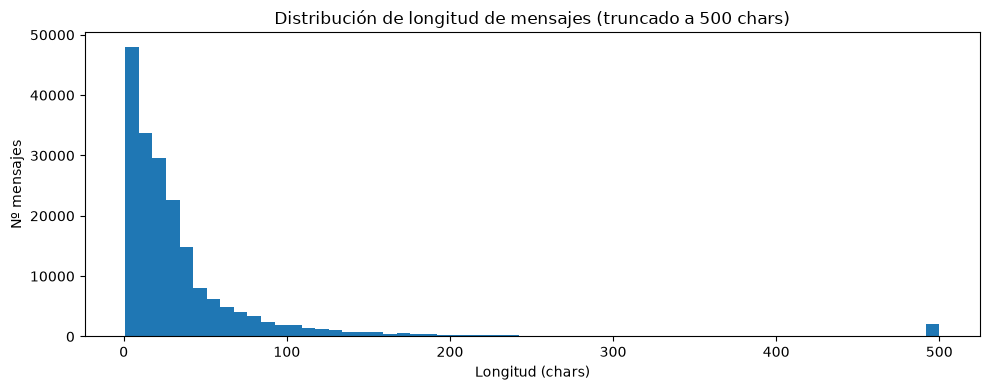

In [9]:
# Creamos una nueva columna 'msg_len' con el número de caracteres de cada mensaje.
# df['message'].str.len() aplica la función len() (longitud de texto) a cada celda
# de la columna 'message'. Es el equivalente a hacer len(texto) para cada fila.
df['msg_len'] = df['message'].str.len()

# describe() genera estadísticas descriptivas de la columna: mínimo, máximo,
# media, desviación estándar, percentiles 25%, 50% y 75%.
# round(1) redondea a un decimal para que sea más legible.
# to_string() muestra todas las estadísticas sin truncar.
print(df['msg_len'].describe().round(1).to_string())
print()

# Mostramos cuántos mensajes son muy cortos (menos de 5 caracteres, como "!!!" o "ok")
# y cuántos son muy largos (más de 500 caracteres, como bloques de código o credenciales).
# (df.msg_len < 5) crea una serie de valores True/False; .sum() cuenta los True.
print(f'Mensajes < 5 chars  : {(df.msg_len < 5).sum():,}')
print(f'Mensajes > 500 chars: {(df.msg_len > 500).sum():,}')

# Creamos la figura para el histograma de longitudes.
fig, ax = plt.subplots(figsize=(10, 4))

# Dibujamos un histograma que muestra cuántos mensajes hay de cada longitud.
# clip(upper=500) limita los valores a 500 como máximo, para que los mensajes
# muy largos no "aplasten" el histograma y no se vea la distribución principal.
# bins=60 divide el rango en 60 barras verticales.
# edgecolor='none' quita el borde de cada barra para una apariencia más limpia.
ax.hist(df['msg_len'].clip(upper=500), bins=60, edgecolor='none')

# Añadimos título y etiquetas.
ax.set_title('Distribución de longitud de mensajes (truncado a 500 chars)')
ax.set_xlabel('Longitud (chars)')
ax.set_ylabel('Nº mensajes')
plt.tight_layout()
plt.show()